# Student Performance Prediction

## Objective
Predict student exam performance based on study habits, attendance, parental involvement, and other academic factors.

# Import the required libraries

In [13]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Objective
Import the  dataset csv file and access it using the pandas library

In [2]:
db = pd.read_csv("Student_performance_data _.csv")

# Objective
Check the data of csv file number of columns and top 5 entries

In [3]:
print("Output")
print(db.head())

Output
   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929196         2.0  
1          

print the details of every column its data type, Not-Null Count,column name

In [4]:
db.info()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


print the number of null values in each column

# Objective
convert every heading to capital for better accessing

In [5]:
db.columns = db.columns.str.upper()

In [6]:
print(db.isnull().sum())
print("-----------------------------------------------")
print("Duplicate Values", db.duplicated().sum())

STUDENTID            0
AGE                  0
GENDER               0
ETHNICITY            0
PARENTALEDUCATION    0
STUDYTIMEWEEKLY      0
ABSENCES             0
TUTORING             0
PARENTALSUPPORT      0
EXTRACURRICULAR      0
SPORTS               0
MUSIC                0
VOLUNTEERING         0
GPA                  0
GRADECLASS           0
dtype: int64
-----------------------------------------------
Duplicate Values 0


# Key Observation
- There are no null values in any column
- there are no duplicate entries in the dataset

describe each column using different aspacts

In [7]:
db.describe()

,STUDENTID,AGE,GENDER,ETHNICITY,PARENTALEDUCATION,STUDYTIMEWEEKLY,ABSENCES,TUTORING,PARENTALSUPPORT,EXTRACURRICULAR,SPORTS,MUSIC,VOLUNTEERING,GPA,GRADECLASS
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


# Objective

plot a histogram of the data based on GPA to check the average GPA distribution
data is plot on 0.5 GPA gaps 

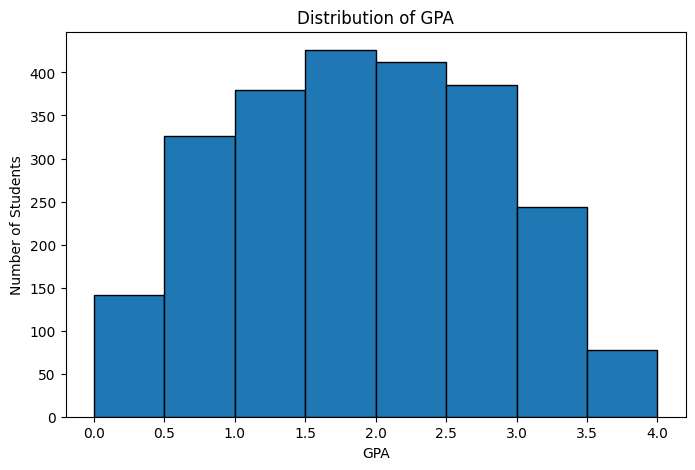

In [8]:
plt.figure(figsize=(8,5))
plt.hist(db["GPA"], bins = 8, edgecolor="black")
plt.title("Distribution of GPA")
plt.xlabel("GPA")
plt.ylabel("Number of Students")
plt.show()

# Key Observation
- Data is concentrated towards centre and is not skewed at either side
- maximum student have GPA between 1.5 to 2.0
- there are minimum student who have GPA greater than 3.5

# Objective

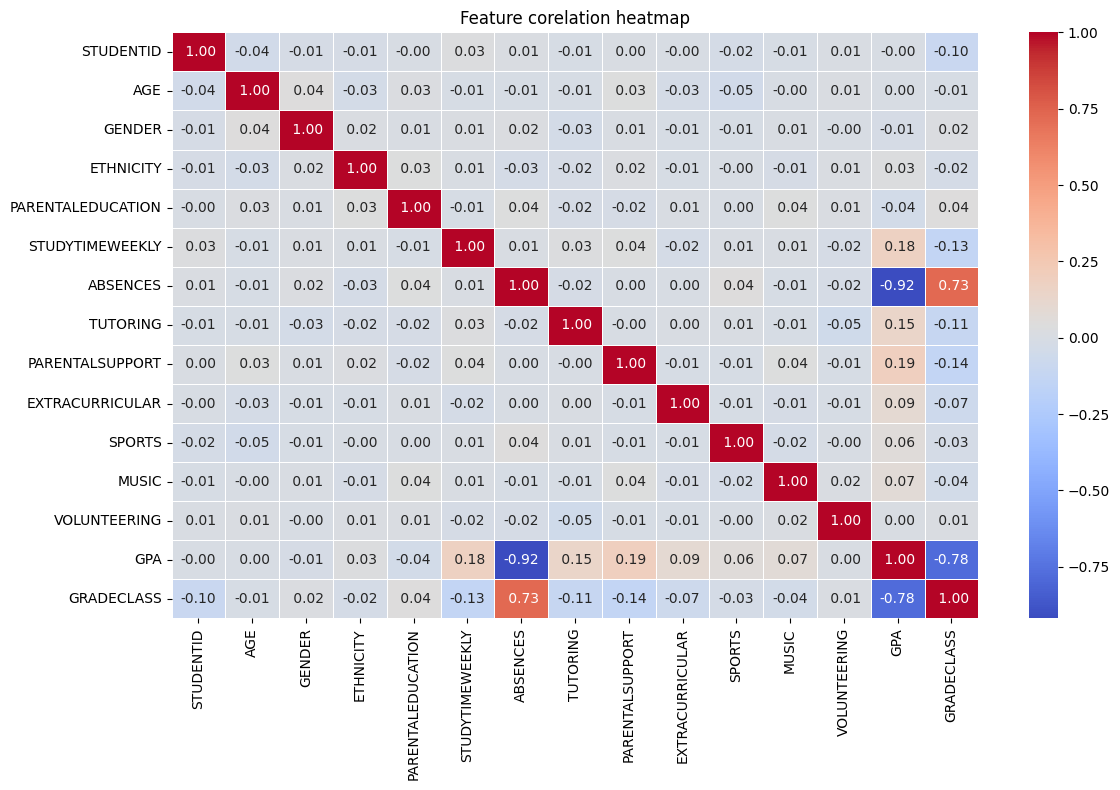

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(
    db.corr(),
    annot=True,
    fmt = " .2f",
    cmap="coolwarm",
    linewidths= 0.5
)
plt.title('Feature corelation heatmap')
plt.tight_layout()
plt.savefig("Corelation_heatmap.png", dpi = 150)
plt.show()


In [10]:
target_col = 'GRADECLASS'
correlations = db.corr()[target_col].drop(target_col)
print(correlations.sort_values(ascending=False))

ABSENCES             0.728633
PARENTALEDUCATION    0.041031
GENDER               0.022998
VOLUNTEERING         0.013156
AGE                 -0.006250
ETHNICITY           -0.023326
SPORTS              -0.026654
MUSIC               -0.036065
EXTRACURRICULAR     -0.069733
STUDENTID           -0.098500
TUTORING            -0.111695
STUDYTIMEWEEKLY     -0.134131
PARENTALSUPPORT     -0.136823
GPA                 -0.782835
Name: GRADECLASS, dtype: float64


# Output
EDA identifies that Absence and Parental support are dominant pridictor of student grade class (r = '0.72' r = '-0.13') and student grade class does not depend on Student ID 

In [11]:
training_model = db.drop(columns=['STUDENTID', 'GRADECLASS', 'GPA'])
Testing = db['GRADECLASS']

print(training_model.shape)
print(training_model.columns)


(2392, 12)
Index(['AGE', 'GENDER', 'ETHNICITY', 'PARENTALEDUCATION', 'STUDYTIMEWEEKLY',
       'ABSENCES', 'TUTORING', 'PARENTALSUPPORT', 'EXTRACURRICULAR', 'SPORTS',
       'MUSIC', 'VOLUNTEERING'],
      dtype='str')


In [14]:
training_model_train, training_model_test, Testing_train, Testing_test = train_test_split(
    training_model, Testing, test_size= 0.25, random_state= 42
)
print(training_model_train.shape, training_model_test.shape)

(1794, 12) (598, 12)


In [15]:
print(Testing.value_counts())
print(Testing.value_counts(normalize=True).round(2))

GRADECLASS
4.0    1211
3.0     414
2.0     391
1.0     269
0.0     107
Name: count, dtype: int64
GRADECLASS
4.0    0.51
3.0    0.17
2.0    0.16
1.0    0.11
0.0    0.04
Name: proportion, dtype: float64
